<a href="https://colab.research.google.com/github/davidsjohnson/xai_ac_wise25/blob/main/notebooks/exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XAI for Affective Computing (WiSe2025)
# Exercise 3:  Explanations for Images of Facial Expressions (WiSe2025)

In this notebook you will attempt to generate explanations for predictions of a facial expression recognition (FER) CNN trained on raw image data, using a subset of the [AffectNet dataset](http://mohammadmahoor.com/affectnet/). AffectNet is an image dataset of facial expressions in the wild, and is labeled with 8 facial expression categories: **Neutral, Happy, Sad, Surprise, Fear, Disgust, Anger, and Contempt**. (Have a look at the paper for more details https://arxiv.org/abs/1708.03985).


To generate explanations, you will use a variety of approaches including LIME, SHAP, Anchors and GradCAM. More information is provided throughout the noteobok.

To use this notebook, please make sure to go step by step through each of the cells review the code and comments along the way.

***NOTE**: This notebook runtime could be improved by using a GPU if available.*

## Notebook Setup

If you are running the notebook locally make sure to update the python packages by running `pip install -r requirements.txt` at the command line

In [1]:
try:
    import google.colab
    IN_COLAB = True
    print('Notebook set for COLAB')
except ImportError:
    IN_COLAB = False
    print('Notebook set to run locally.\nMake sure you have installed all required packages in the requirements.txt')

Notebook set for COLAB


In [2]:
if IN_COLAB:
  !git clone https://github.com/davidsjohnson/xai_ac_wise25.git
  %pip install -q shap lime grad-cam zennit

Cloning into 'xai_ac_wise25'...
remote: Enumerating objects: 458, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 458 (delta 20), reused 17 (delta 6), pack-reused 420 (from 3)
Receiving objects: 100% (458/458), 99.35 MiB | 11.72 MiB/s, done.
Resolving deltas: 100% (58/58), done.
Updating files: 100% (397/397), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 42.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.1 MB/s eta 0:00:00


In [3]:
import sys
import os

if IN_COLAB:
  sys.path.append(os.path.realpath('xai_ac_wise25'))
else:
  sys.path.append(os.path.realpath('../'))

In [4]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report

import torch
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import torch.nn as nn

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from PIL import Image

import utils
import img_utils
import models
import evaluate

In [5]:
base_dir = Path('../data/') if not IN_COLAB else Path('xai_ac_wise25/data/')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [6]:
# download the AffectNet dataset extracted features and a sample set of images for visualization
affnet_dir = utils.download_file('https://uni-bielefeld.sciebo.de/s/EmfF9r93LG4jcT9/download',
                          file_name='affectnet_data.zip',
                          cache_dir=base_dir,
                          extract=True,
                          force_download=False,     # set to False if you have already downloaded the dataset
                          archive_folder='affectnet_data')
affnet_dir

File downloaded to: xai_ac_wise25/data/affectnet_data.zip


PosixPath('xai_ac_wise25/data/affectnet_data')

## XAI for FER with  Convoluational Neural Nets

### Setup the Pytorch Data Loader

In [7]:
#class labels
class_names = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']

# Setup XAI Data from AffectNet Deep Learning Model
TRAIN_MEAN = [0.485, 0.456, 0.406]
TRAIN_STD = [0.229, 0.224, 0.225]

# trainsform to preprocess the images
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
    transforms.Resize((224, 224))
])

# set up and load the dataset
data_dir = base_dir / 'affectnet_data/affectnet/val_class'
dataset = datasets.ImageFolder(root=data_dir, transform=test_transform)
images = [Image.open(f[0]).convert('RGB').resize((224,224)) for f in dataset.imgs] # load images as PIL objects and resize them
images = [np.array(img) / 255.0 for img in images] # convert to numpy arrays and rescale for display
y_true = np.array([f[1] for f in dataset.imgs])
y_labels = [class_names[f[1]] for f in dataset.imgs]
dataloader = DataLoader(dataset, batch_size=80, shuffle=False)

### Load Pretrained Model

In [8]:
# download checkpoint
ckpt_link = 'https://uni-bielefeld.sciebo.de/s/0tAa2wPhGxSDjbM/download'
ckpt_path = utils.download_file(ckpt_link,
                                'affectnet.pth',
                                cache_dir= base_dir / 'affectnet/model',
                                extract=False, # checkpoint is not a zip file
                                force_download=False
                                )
ckpt_path

File already exists at: xai_ac_wise25/data/affectnet/model/affectnet.pth


PosixPath('xai_ac_wise25/data/affectnet/model/affectnet.pth')

In [9]:
model = models.ResNet18(n_classes=len(class_names), pretrained=True)
model.to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval();

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 54.0MB/s]


### Evaluation of Model

This model performs much better than the AU dataset, but still with only around $60\%$ accuracy.  But this is pretty close the state-of-the-art for the AffectNet dataset

In [10]:
inverse_weights = torch.from_numpy(1.0/np.array([74874, 134415, 25459, 14090, 6378, 3803, 24882, 3750])).type(torch.float32).to(device)
loss = torch.nn.CrossEntropyLoss(weight=inverse_weights)
_, _, y_preds, probs = evaluate.evaluate_model(model, dataloader, loss, device=device)

y_preds = np.array(y_preds)
# validate predictions and true values
(y_preds == y_true).mean()

Evaluation Loss: 1.3183, Evaluation Accuracy: 0.5875


np.float64(0.5875)

In [11]:
# eval results
print(classification_report(y_true, y_preds, target_names=class_names))

              precision    recall  f1-score   support

     Neutral       0.41      0.70      0.52        10
       Happy       0.82      0.90      0.86        10
         Sad       0.56      0.50      0.53        10
    Surprise       0.86      0.60      0.71        10
        Fear       0.57      0.40      0.47        10
     Disgust       0.78      0.70      0.74        10
       Anger       0.40      0.40      0.40        10
    Contempt       0.50      0.50      0.50        10

    accuracy                           0.59        80
   macro avg       0.61      0.59      0.59        80
weighted avg       0.61      0.59      0.59        80



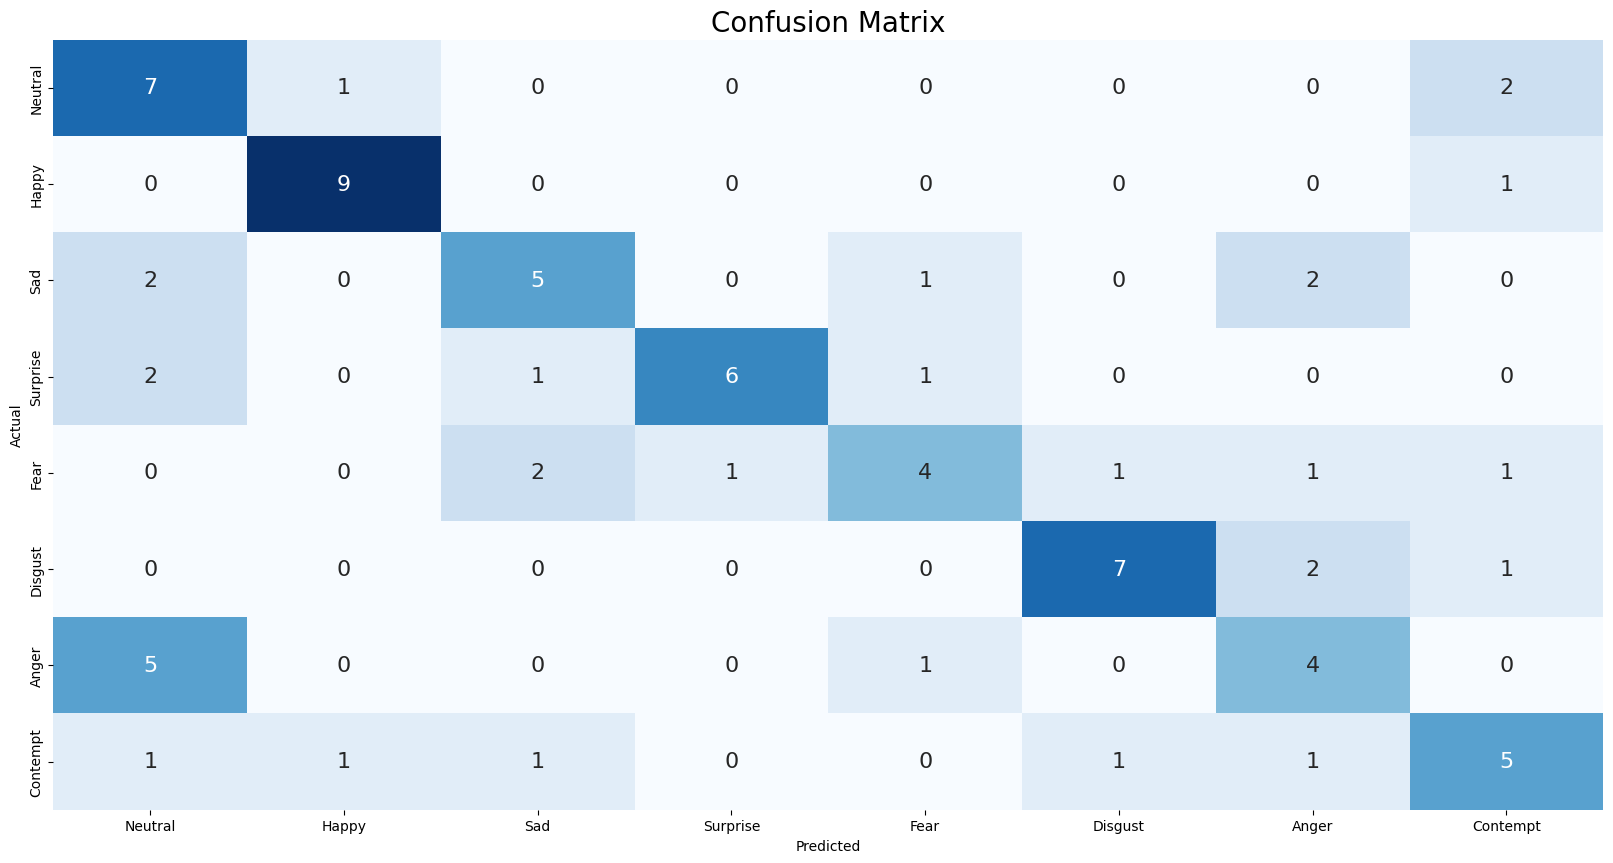

In [12]:
cm_data = confusion_matrix(y_true, y_preds)
cm = pd.DataFrame(cm_data, columns=class_names, index=class_names)
cm.index.name = 'Actual'
cm.columns.name = 'Predicted'
plt.figure(figsize = (20,10))
plt.title('Confusion Matrix', fontsize = 20)
sns.set(font_scale=1.2)
ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

## Generate Explanations

### Task 1: Generate Local Explanations with LIME

In this task, you will use LIME to generate explanations from the CNN model provided above. In the last exercise, you learned about LIME and used it with tabular data.  Now you will use with a model that takes images as input. Review the [LIME paper](https://dl.acm.org/doi/10.1145/2939672.2939778) to better understand how LIME adapts its model simplification approach to images.  

LIME requires images to be segmented into superpixels.  For facial expressions the segmentation algorithm is very important and the default of the `explain_instance()` method may not provide good explanations.  Experiment with different segmenters using the LIME `SegmentationAlgorithm` class and pass to `segmenter_fn` argument of the `explain_instance()` method.

- For example: `segmenter = SegmentationAlgorithm('method name', params)`, where params are defined by the skimage segmentation alorithm method
- by default LIME uses:

```python
segmenter = SegmentationAlgorithm('quickshift', kernel_size=4,
                                  max_dist=200, ratio=0.2,
                                  random_seed=random_seed)
```

You can find different algorithms via [skimage segmentation](https://scikit-image.org/docs/stable/api/skimage.segmentation.html)


#### Completing the Task
- Before getting started with LIME, select 6 image that you want to gain explanations for. Choose 3 correct and 3 incorrect explanations. We will use the same images in the following tasks.

- Then, Implement a [LimeImageExplainer](https://lime-ml.readthedocs.io/en/latest/lime.html#module-lime.lime_image) instance, you can review the [LIME tutorial](https://github.com/marcotcr/lime/blob/master/doc/notebooks/Tutorial%20-%20Image%20Classification%20Keras.ipynb) for help.
- Next, implement and visualize the segment boundaries for the default LIME segmenter and at least one other segementation algorithm. You should also alter some of the various hyperpameters for each algorithm to find an approach you feel works best.  Choose the algorithm and hyperparameters which you think are best for generating a LIME explanation on facial expression recognition.
- Now generate and visualize the explanations for each of you selected images. Experiment with the default segmenter and another segmenter as found above in task 2.2a


Hint: to quickly display images with a title, you can use the function `img_utils.display_one_image`. The function takes three inputs, an image, a title and a subplot tuple in the form (nrows, ncols, current_index). The subplot tuple allows you to plot multiple images in one plot similar to matplotlib

In [13]:
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

from skimage.segmentation import mark_boundaries # used to get boundries from explanation for plotting

**Preview the Dataset with Predictions**

The code below will display images from the XAI dataset.
- Try changing value of `start` to get a new set of images (there are 10 images for each class; for example, the class happy will be at indexes 10-19)
- Search through the images to find some that might be interesting to Explain

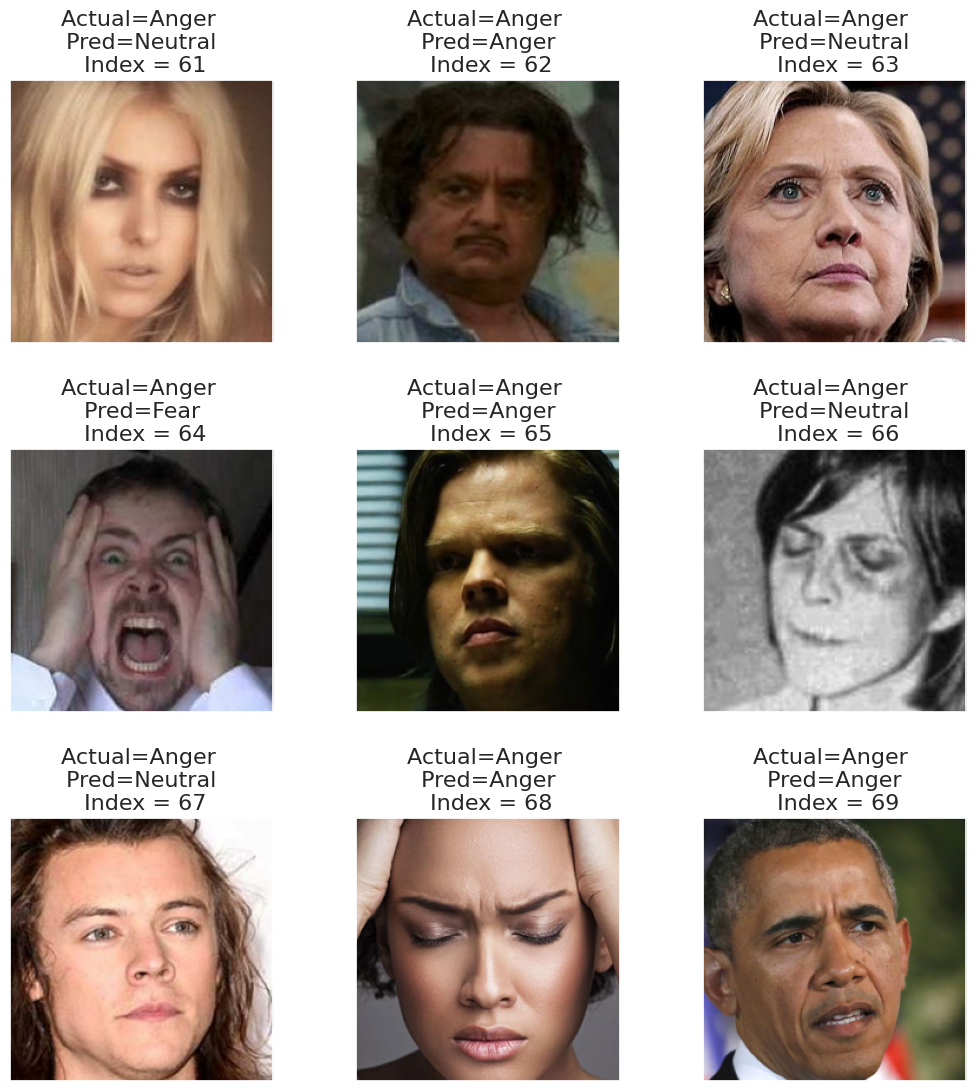

In [14]:
start=61
img_utils.display_nine_images(images, y_true, y_preds, start)

In [15]:
####### Select Your images #######
##################################

img_idxs_corr = [65, 69]
img_idxs_incorr = [64, 67]

all_idxs = img_idxs_corr + img_idxs_incorr

In [16]:
# model wrapper for lime
def f(x):
    tensors = []
    pil_images = [Image.fromarray((img * 255).astype(np.uint8)).convert('RGB') for img in x]
    for img in pil_images:
      out = test_transform(img)
      tensors.append(out)
    tensors = torch.stack(tensors).to(device)
    with torch.no_grad():
        y = model(tensors)
    return F.softmax(y, dim=1).cpu().numpy()

In [17]:
##### YOUR CODE GOES HERE #####
###############################


### Task 2: Generate Local Explanations with LRP

In this task, you will generate **Layerwise Relevance Propagation (LRP)** explanations using the **Zennit** library, which we discussed in the seminar.

Zennit is a Python framework designed for visualizing neural networks, with strong focus on LRP. To get started, review the [Zennit documentation](https://zennit.readthedocs.io/en/latest/), especially the *Getting Started* section. That should be sufficient for this assignment, but feel free to explore additional sections for a deeper understanding.



### To complete this task

1. Implement a function to compute relevance values using Zennit.
Your function should:

    - Accept the following inputs:
      - an image,
      - a class index,
      - the prediction model,
      - a Zennit composite.
    - Apply the `test_transform` to the image.
    - Convert the class index into a one-hot vector.
    - Use Zennit to compute the attribution (relevance) values.
    - Return the attribution map as a **single-channel NumPy array**.


2. Implement a function to overlay the attribution map on the original image.
Your function should:

    - Accept the image, the attribution map, and an `alpha` value (to control transparency).
    - Normalize the attribution values and apply a Matplotlib colormap (e.g., `seismic`).
    - Optionally apply a Gaussian blur to smooth the relevance values.
    - Convert the original image to grayscale.
    - Combine the grayscale image with the normalized attribution heatmap.
    - Return the final visualization as a Pillow Image


3. Generate and visualize explanations.

- For each image you selected earlier:

    - Generate the combined heatmap-plus-image visualization for the **predicted class**.
    - If the prediction is **incorrect**, also generate a visualization for the **true class**.
    - Optional: Create a grid of explanations, where each row corresponds to one facial expression image and each column corresponds to a different class, allowing you to compare relevance patterns across classes.

4. Perform the above steps with at least two of the `composites` from Zennit.

In [18]:
from zennit.attribution import Gradient
from zennit.torchvision import ResNetCanonizer
from zennit.composites import *

In [19]:
##### YOUR CODE GOES HERE #####
###############################


### Task 3: General Local Explanations with SHAP

In this task, you will generate [SHAP-based explanations](https://shap.readthedocs.io).  You will use the basic SHAP partition explainer which is a model-agnostic approach to generating explanations. See the ["Explain ResNet50 ImageNet using Partition Explainer"](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Image%20Multi%20Class.html) example for detail on how to implement it.  

Altough, the example is for Tensorflow, the main idea stays the same.  You will need a `masker` and a `model` wrapper that takes an array of raw images, applies the image transform and returns the probabilities for each image.

Note: since AffectNet images are all different resolutions, I've included code to resize all the images before sending to SHAP. Thie makes it easier to deal with all images at once (rather than looping).

#### To complete this task:

- Use the same images from the previous tasks.
- Implement a function that wraps the pytorch model to allow for input in the form of raw images as numpy arrays, and outputs the model predictions.  Remember to use the `test_transform` on the images to apply normalization.  
- Then, generate a SHAP explainer, initialized with the wrapper function and a masker. You may want to experiment with different types of maskers.  
- Finally, generate and visualize the SHAP explanations for each image.  The visualization should be similar to the example from the tutorial. This means you should plot the saliency maps in the order of their prediction probabilities (but for all classes not just the first 4).


In [20]:
import shap

In [21]:
# resize images so they all can be explained together
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.ToPILImage()
])
images_resized = np.array([transform(x) for x in images])

In [22]:
##### YOUR CODE GOES HERE #####
###############################



### Task 4 - Generate Local Explanations with GradCAM

In this task, you generate Gradient-Weighted Class Activation Maps (GradCAM) explanations for the images.  GradCAM is another commonly used feature-based approach and was popularized with the paper [Grad-CAM:
Visual Explanations from Deep Networks via Gradient-based Localization](https://ieeexplore.ieee.org/document/8237336). The main idea of GradCAM is use use the gradients of a target output to create a weighted sum of activation maps from the final layer in the network. This generates a course localization of important regions of the input image for a specified output.  

For this task, you will use the [`pytorch-grad-cam` python package](https://jacobgil.github.io/pytorch-gradcam-book/introduction.html)


#### To complete this task:

- Use the same images from the previous tasks.
- Review the [grad-cam introduction](https://jacobgil.github.io/pytorch-gradcam-book/introduction.html) for details on implementing grad-cam using this package.
- Implement a standard GradCAM explainer for the last layer of the network. Provided in the below code in the variable `target_layers`.
- For the images that were correctly predicted by the network, visualize the GradCAM output for the predicated class.
- For the images that were incorrectly predicted by the network, visualize both the explanations for the prediction and the ground truth.  

In [23]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [24]:
###### Enter your Code Below ######
##################################


### Task 5: Discuss your findings.

For this task, you will answer the following questions regarding your experiences with the above XAI approaches.

1. You used four explanation techniques: LIME, SHAP, LRP, and GradCAM. Explain the main differences in the techniques and how this affects the interpretation of the output explanations.
2. What is the difference between the SHAP `PartitionExplainer` and the other image explainers available in the SHAP library, such as the `DeepExplainer`.
3. Explain the purpose of the Zennit `composites`. Which two did you select for task 2 and what are the differences between how they calculate relevances?
2. Which explanation method produced the most intuitive result for you? Why do you think it was easier to interpret?
3. Were there any explanation methods that produced results that surprised you or seemed incorrect? What might be the reason?
4. Imagine you are building a real-world system that uses facial expressions for mental health assessment, like the recognition of social anxiety. Which explanation method would you use to justify your model’s decision to an end user (e.g., a psychologist)? How would you visualize or communicate the explanation?

Write your answers here...